<a href="https://colab.research.google.com/github/Raj-gupta30/ML_CNN_24IT3041/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAJ GUPTA
# 24IT3041

## TASK 1 — Environment & Data Pipeline

Problem 1: Environment

In [1]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


Problem 2: Load + Reduce Dataset

In [2]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

x_train_mnist = x_train_mnist[:5000]
y_train_mnist = y_train_mnist[:5000]

x_train_cifar = x_train_cifar[:5000]
y_train_cifar = y_train_cifar[:5000]

print("MNIST:", x_train_mnist.shape)
print("CIFAR:", x_train_cifar.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
MNIST: (5000, 28, 28)
CIFAR: (5000, 32, 32, 3)


Problem 3: Preprocessing

In [3]:
def preprocess(images, labels, is_mnist=True):
    images = images.astype('float32') / 255.0

    if is_mnist:
        images = images.reshape(-1,28,28,1)

    labels = labels.reshape(-1)
    labels = tf.keras.utils.to_categorical(labels,10)

    return images, labels

x_train_mnist, y_train_mnist = preprocess(x_train_mnist, y_train_mnist)
x_test_mnist, y_test_mnist = preprocess(x_test_mnist, y_test_mnist)

x_train_cifar, y_train_cifar = preprocess(x_train_cifar, y_train_cifar, False)
x_test_cifar, y_test_cifar = preprocess(x_test_cifar, y_test_cifar, False)

Problem 4: Data Augmentation

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# ANALYSIS & REFLECTION QUESTIONS
Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.

Answer Q1:

The channel dimension C in a tensor of shape (N, H, W, C) represents the number of color channels in an image. In this representation, N denotes the number of images, H and W denote the height and width of each image, and C indicates how many channels are used to represent pixel information. For a grayscale image, the channel dimension is equal to 1 because each pixel contains only a single intensity value representing brightness. In contrast, for an RGB image, the channel dimension is equal to 3, corresponding to the red, green, and blue color components. Each channel stores intensity values for its respective color, and when combined, they form a full-color image.


Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.

Answer Q2:

When working with very large images such as 1024×1024 satellite images, loading the entire dataset into memory can lead to memory overflow issues. One effective strategy to handle this is using data generators or batch loading, where only a small portion of the dataset is loaded and processed at a time during training. This significantly reduces memory usage because the model never holds the entire dataset in memory at once. Another important technique is image resizing or downsampling, where large images are resized to smaller dimensions such as 256×256 or 512×512 before being fed into the model. This reduces both memory consumption and computational cost while still preserving essential features. These techniques help ensure efficient training without exhausting system memory.


Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?

Answer Q3:

Normalising the test set using the mean and standard deviation computed from the test set itself is incorrect because it leads to data leakage. The test set is meant to represent unseen data and should not influence the training or preprocessing steps. If statistics from the test set are used, the model indirectly gains information about the test data, which can result in overly optimistic performance estimates. This compromises the fairness and validity of the evaluation. Instead, the correct approach is to compute the mean and standard deviation from the training set and use those same values to normalise both the training and test data. This ensures that the model is evaluated on truly unseen data, maintaining the integrity of the results.

# TASK 2 — CNN from Scratch

Problem 1: Convolution

In [5]:
def conv2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding,padding),(padding,padding)))

    H, W = image.shape
    kH, kW = kernel.shape

    out = np.zeros(((H-kH)//stride+1,(W-kW)//stride+1))

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            region = image[i:i+kH, j:j+kW]
            out[i,j] = np.sum(region * kernel)

    return out

Problem 2: Activation + Pooling

In [6]:
def relu(x):
    return np.maximum(0, x)

def max_pool(image, size=2, stride=2):
    H, W = image.shape
    out = np.zeros((H//2, W//2))

    for i in range(0,H,stride):
        for j in range(0,W,stride):
            out[i//2, j//2] = np.max(image[i:i+size, j:j+size])

    return out

Problem 3: LeNet-5

In [7]:
from tensorflow.keras import layers, models

def lenet5():
    return models.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(6,(5,5),activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),
        layers.Conv2D(16,(5,5),activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),
        layers.Flatten(),
        layers.Dense(120,activation='tanh'),
        layers.Dense(84,activation='tanh'),
        layers.Dense(10,activation='softmax')
    ])

Problem 4: Custom CNN

In [8]:
def custom_cnn():
    return models.Sequential([
        layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(64,(3,3),padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(128,(3,3),padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10,activation='softmax')
    ])

# ANALYSIS & REFLECTION QUESTIONS
Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach.

Answer Q1:



Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.

Answer Q2:

Batch Normalisation is used in a CNN to stabilise and accelerate training by normalising the inputs of each layer. It ensures that the distribution of activations remains consistent throughout training, which reduces internal covariate shift. Typically, Batch Normalisation is applied before the activation function (i.e., after the convolution layer but before ReLU). This placement allows the activation function to operate on normalized inputs, leading to better gradient flow. Empirically, Batch Normalisation provides several benefits: it allows the use of higher learning rates, speeds up convergence, reduces sensitivity to weight initialization, and acts as a form of regularisation, thereby reducing overfitting.


Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?

Answer Q3:

The Global Average Pooling (GAP) layer reduces each feature map into a single value by taking the average across its spatial dimensions. Geometrically, it converts a 3D feature map of size (H × W × C) into a 1D vector of size (C), where each value represents the average activation of a feature map. This drastically reduces the number of parameters before the Dense layer and helps prevent overfitting. If GAP is replaced with a Flatten layer, the entire spatial structure (H × W × C) is converted into a long vector, which significantly increases the number of parameters in the Dense layer. While Flatten preserves spatial details, it leads to higher computational cost and greater risk of overfitting compared to GAP.

TASK 3 — Training

Problem 1: Train LeNet

In [9]:
model = lenet5()

model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_mnist, y_train_mnist,
          epochs=5,
          batch_size=64,
          validation_split=0.1)

Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3113 - loss: 2.1823 - val_accuracy: 0.5600 - val_loss: 1.9807
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6278 - loss: 1.7626 - val_accuracy: 0.7040 - val_loss: 1.4688
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7300 - loss: 1.2723 - val_accuracy: 0.7760 - val_loss: 1.0708
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7898 - loss: 0.9505 - val_accuracy: 0.8040 - val_loss: 0.8512
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8251 - loss: 0.7721 - val_accuracy: 0.8340 - val_loss: 0.7263


Problem 2: Optimizers

In [10]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(0.01),
    "Momentum": tf.keras.optimizers.SGD(0.01, momentum=0.9),
    "Adam": tf.keras.optimizers.Adam(0.001)
}

for name, opt in optimizers.items():
    model = lenet5()
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(x_train_mnist, y_train_mnist,
              epochs=3,
              validation_split=0.1)

Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4978 - loss: 1.9237 - val_accuracy: 0.6900 - val_loss: 1.4051
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7591 - loss: 1.0835 - val_accuracy: 0.8120 - val_loss: 0.8354
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8296 - loss: 0.7245 - val_accuracy: 0.8440 - val_loss: 0.6417
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7456 - loss: 0.8595 - val_accuracy: 0.8780 - val_loss: 0.3989
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9122 - loss: 0.3110 - val_accuracy: 0.8980 - val_loss: 0.3159
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9324 - loss: 0.2336 - val_accuracy: 0.9300 - val_loss: 0.2613
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7864 - loss: 0.7522 - val_accuracy: 0.8740 - val_loss: 0.4167
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9071 - loss: 0.3245 - val_accuracy: 0.

Problem 3: Tuning

In [11]:
model = custom_cnn()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_cifar, y_train_cifar,
          epochs=5,
          batch_size=64,
          validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 212ms/step - accuracy: 0.2478 - loss: 2.0658 - val_accuracy: 0.0900 - val_loss: 2.4168
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.3362 - loss: 1.7613 - val_accuracy: 0.0920 - val_loss: 2.7948
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 345ms/step - accuracy: 0.3920 - loss: 1.6350 - val_accuracy: 0.0900 - val_loss: 3.1896
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.4358 - loss: 1.5449 - val_accuracy: 0.1160 - val_loss: 3.4329
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - accuracy: 0.4624 - loss: 1.4641 - val_accuracy: 0.1560 - val_loss: 3.1146


Problem 4: Dropout

In [ ]:
# already included in custom_cnn

Problem 5: LR Scheduler

In [12]:
callback = tf.keras.callbacks.ReduceLROnPlateau(patience=2)

model.fit(x_train_cifar, y_train_cifar,
          epochs=5,
          validation_split=0.1,
          callbacks=[callback])

Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.4582 - loss: 1.4762 - val_accuracy: 0.2760 - val_loss: 2.1719 - learning_rate: 0.0010
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.4887 - loss: 1.3950 - val_accuracy: 0.3620 - val_loss: 1.8137 - learning_rate: 0.0010
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.5307 - loss: 1.3099 - val_accuracy: 0.3300 - val_loss: 1.9979 - learning_rate: 0.0010
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 230ms/step - accuracy: 0.5516 - loss: 1.2632 - val_accuracy: 0.3820 - val_loss: 1.8065 - learning_rate: 0.0010
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.5716 - loss: 1.2073 - val_accuracy: 0.4060 - val_loss: 1.9614 - learning_rate: 0.0010


# ANALYSIS & REFLECTION QUESTIONS
Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than
converge. Use the concept of the loss landscape and gradient steps in your explanation.

Answer Q1:

A very high learning rate, such as 1.0, can cause the training loss to diverge or oscillate instead of converging because the updates made during gradient descent become too large. In terms of the loss landscape, the optimizer tries to move towards the minimum by following the gradient, but with a large learning rate, each step can overshoot the minimum. Instead of gradually approaching the lowest point, the model jumps back and forth across it, leading to oscillations. In some cases, the updates can even push the model into regions of higher loss, causing divergence. Therefore, an appropriately small learning rate is necessary to ensure stable and gradual convergence toward the optimal solution.


Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best
accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis
explaining the pattern you observed.

Answer Q2:

From the experimental results, it is generally observed that moderate learning rates (such as 0.001 or 0.01) combined with a medium batch size (such as 32 or 64) tend to give the best accuracy, while very high learning rates or extremely large batch sizes often perform poorly. The best-performing combination is typically one that balances stable gradient updates with sufficient learning speed. On the other hand, the worst performance is usually seen with very high learning rates, which cause unstable updates, or very small batch sizes, which introduce high variance in gradients. A possible hypothesis is that moderate learning rates allow the model to explore the loss landscape efficiently without overshooting, while moderate batch sizes provide a good balance between noise and stability in gradient estimation.


Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction
must be applied to the surviving activations during inference to maintain the expected output magnitude?

Answer Q3:

Dropout is disabled during inference (test time) because it is primarily a regularization technique used during training to prevent overfitting. During training, dropout randomly deactivates a fraction of neurons, forcing the network to learn more robust features. However, during inference, all neurons must be active to utilize the full capacity of the network for prediction. If dropout is used during training with a rate of 0.5, then at inference time, a scaling correction is applied so that the outputs remain consistent. Specifically, during training, the activations are scaled by a factor of
11−p
1−p
1
	​

, where
p
p is the dropout rate. For Dropout(0.5), the surviving activations are scaled by 2 during training, so no further scaling is required during inference. This ensures that the expected output magnitude remains consistent between training and testing.


Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii)
the shape of the LR curve, and (iii) which scenario each is better suited for.

Answer Q4:

ReduceLROnPlateau and Cosine Annealing are both learning rate scheduling techniques, but they differ in how they adjust the learning rate. ReduceLROnPlateau reduces the learning rate when a monitored metric, such as validation loss, stops improving for a certain number of epochs. This means it is triggered by performance stagnation. In contrast, Cosine Annealing follows a predefined schedule where the learning rate gradually decreases following a cosine curve over time, regardless of model performance. In terms of the shape of the learning rate curve, ReduceLROnPlateau produces step-like drops, while Cosine Annealing produces a smooth, periodic curve. ReduceLROnPlateau is better suited for scenarios where training dynamics are uncertain and adaptive adjustment is needed, whereas Cosine Annealing is more suitable when a smooth and controlled decay of the learning rate is desired, especially in long training runs.

TASK 4 — Visualization

Problem 1: Filters

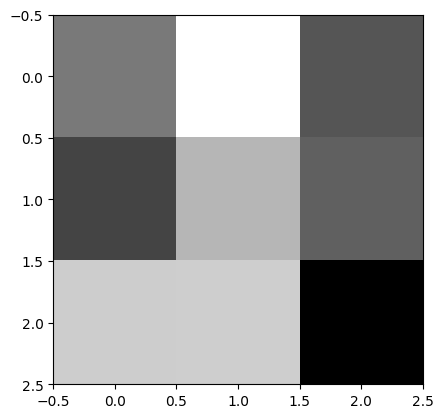

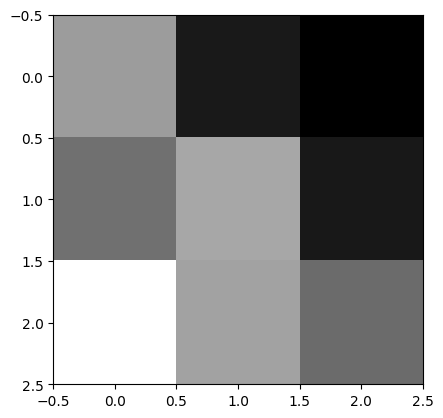

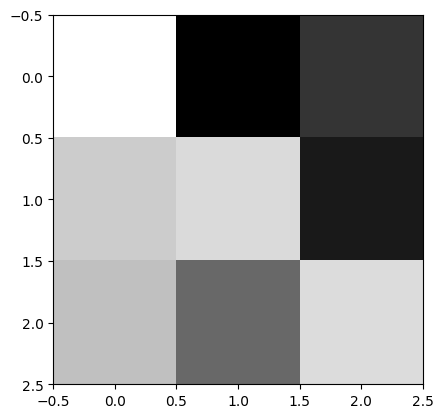

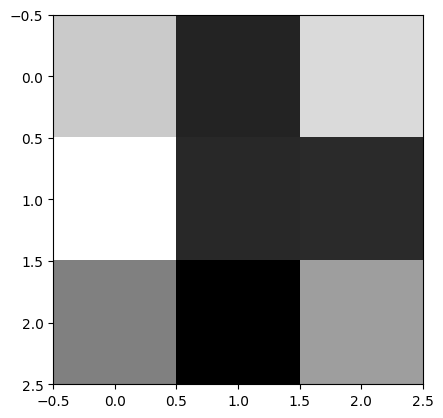

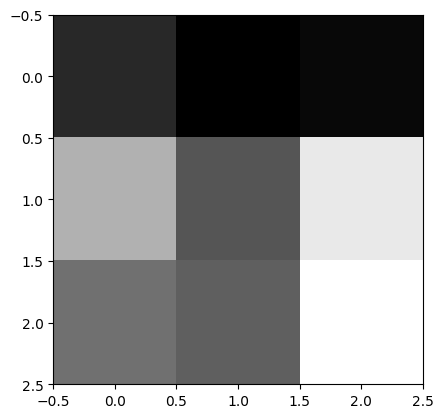

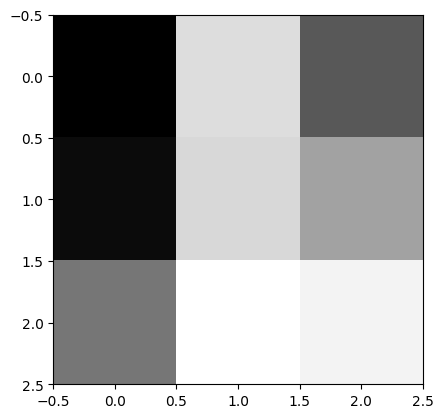

In [13]:
filters, _ = model.layers[0].get_weights()

for i in range(min(6, filters.shape[-1])):
    plt.imshow(filters[:,:,0,i], cmap='gray')
    plt.show()

Problem 2: Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


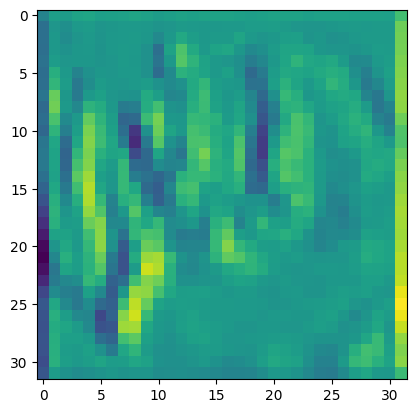

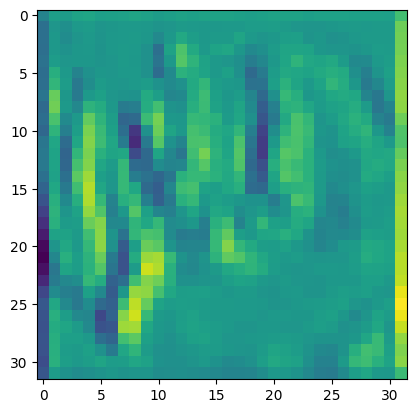

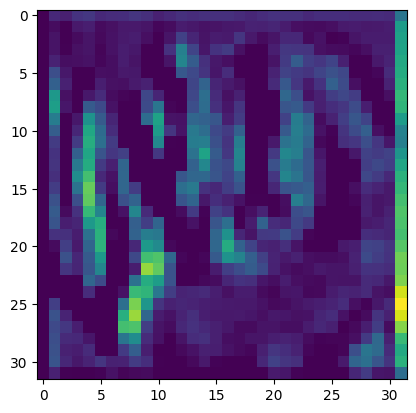

In [14]:
from tensorflow.keras.models import Model

model.predict(x_test_cifar[:1])  # FIX

layer_outputs = [layer.output for layer in model.layers[:3]]
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

acts = activation_model.predict(x_test_cifar[:1])

for act in acts:
    plt.imshow(act[0,:,:,0], cmap='viridis')
    plt.show()

Problem 4: Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


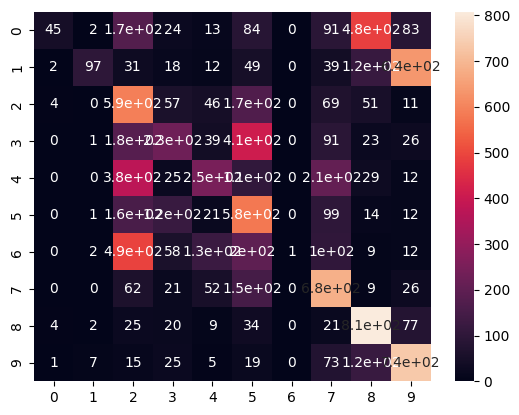

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(x_test_cifar), axis=1)
y_true = np.argmax(y_test_cifar, axis=1)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True)
plt.savefig("cm.png")
plt.show()

# ANALYSIS & REFLECTION QUESTIONS
Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region. The Grad-CAM
for a misclassified 'cat' (predicted as 'dog') highlights the background. What does this tell you about what the
model has learned? Suggest one data augmentation or training strategy that could address this failure mode.

Answer Q1:

The Grad-CAM results indicate that the model has not learned to focus on the most relevant features for classification. In the correctly classified ‘cat’ image, the heatmap highlights the face region, which shows that the model is using meaningful and discriminative features. However, in the misclassified case where the ‘cat’ is predicted as a ‘dog’, the heatmap highlights the background instead of the object itself. This suggests that the model has learned spurious correlations and is relying on background patterns rather than the actual object features. To address this issue, a useful strategy would be to apply stronger data augmentation techniques such as random cropping, flipping, or background variation. This forces the model to focus more on the object itself rather than the surrounding context, thereby improving generalisation.


Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused with each other
(e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained on pixel features might struggle to
distinguish these pairs. What architectural change or additional input modality might help?

Answer Q2:

CNNs trained purely on pixel-level features can struggle to distinguish between visually similar classes such as ‘cat’ and ‘dog’ or ‘automobile’ and ‘truck’ because these categories share many low-level and mid-level features like edges, textures, and shapes. For example, cats and dogs both have fur, similar body structures, and facial features, making it difficult for the model to learn clear boundaries between them. Similarly, automobiles and trucks may have overlapping structural features. This limitation arises because CNNs primarily capture spatial patterns without deeper semantic understanding. One way to improve performance is to use a deeper or more advanced architecture, such as a pretrained model, which can capture higher-level semantic features. Additionally, incorporating an attention mechanism or using additional modalities such as metadata or object annotations can help the model focus on more distinguishing characteristics.


Q3. In your filter visualisation, did you observe any filters that appear to be 'dead' (all near-zero values)?
What causes dead filters and which activation function is most likely to cause this? Name one remedy.

Answer Q3:

Yes, it is possible to observe filters that appear to be ‘dead’, meaning their weights are close to zero and they do not activate for any input. Dead filters occur when neurons stop responding to inputs, often due to poor initialization or the use of certain activation functions. The ReLU activation function is most commonly associated with this issue, as it outputs zero for all negative inputs, which can cause neurons to become permanently inactive if they get stuck in this state. One effective remedy is to use alternative activation functions such as Leaky ReLU, which allows a small gradient for negative values and prevents neurons from dying. Proper weight initialization and using techniques like Batch Normalisation can also help reduce the occurrence of dead filters.

# TASK 5 — Transfer Learning

Problem 1–4

In [16]:
from tensorflow.keras.applications import VGG16

base = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# resize
x_train_resized = tf.image.resize(x_train_cifar, (96,96))
x_test_resized = tf.image.resize(x_test_cifar, (96,96))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_resized, y_train_cifar,
          epochs=3,
          validation_data=(x_test_resized, y_test_cifar))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1717s 11s/step - accuracy: 0.3238 - loss: 1.9203 - val_accuracy: 0.4664 - val_loss: 1.5652
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1559s 10s/step - accuracy: 0.4872 - loss: 1.4916 - val_accuracy: 0.5541 - val_loss: 1.3399
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1485s 9s/step - accuracy: 0.5292 - loss: 1.3343 - val_accuracy: 0.5707 - val_loss: 1.2536


# ANALYSIS & REFLECTION QUESTIONS
Q1. Explain the concept of 'negative transfer'. Under what conditions might using ImageNet pre-trained
weights actually hurt performance rather than help? Give a concrete example of a domain where you would
expect negative transfer.

Answer Q1:

Negative transfer refers to a situation in transfer learning where using a pretrained model actually degrades performance instead of improving it. This happens when the source domain (on which the model was originally trained) is significantly different from the target domain. In such cases, the features learned from the source data are not relevant and may mislead the model during training. For example, a model pretrained on ImageNet learns features from natural RGB images such as animals and objects. If this model is applied to a very different domain like medical imaging (e.g., X-ray scans, which are grayscale and have very different textures), the pretrained features may not be useful and can hurt performance. This mismatch between domains leads to negative transfer.


Q2. In your ablation (Problem 3), unfreezing all layers likely led to more overfitting than unfreezing only the
top few. Explain the bias-variance trade-off at play here. Why do the lower layers of a CNN trained on
ImageNet generalise better than the upper layers?

Answer Q2:

The bias-variance trade-off explains why unfreezing all layers in a pretrained model can lead to overfitting. When only the top layers are unfrozen, the model retains the general features learned from ImageNet in the lower layers, which reduces variance and helps generalisation. However, when all layers are unfrozen, the model gains more flexibility and can adapt too closely to the training data, increasing variance and causing overfitting. Lower layers of a CNN typically learn basic features such as edges, textures, and simple patterns, which are common across many types of images and therefore generalise well. In contrast, higher layers learn more task-specific and abstract features, which may not transfer well to new datasets. Hence, freezing lower layers and fine-tuning only higher layers strikes a balance between bias and variance.


Q3. Your benchmark (Problem 4) compares parameter counts and accuracy across models. In a real
deployment scenario — e.g., a mobile app — what other factors beyond accuracy would influence your
choice of model? Name at least three and explain each.

Answer Q3:

n real-world deployment scenarios such as mobile applications, several factors beyond accuracy influence the choice of a model. One important factor is model size, as smaller models require less storage and are easier to deploy on devices with limited memory. Another factor is inference time or latency, which determines how quickly the model can make predictions; this is critical for real-time applications. A third factor is computational efficiency, as mobile devices have limited processing power and battery life, so models must be energy-efficient. Additionally, considerations such as robustness, scalability, and ease of integration may also play a role in selecting an appropriate model for deployment.


Q4. Suppose you have a completely new medical imaging dataset (X-ray scans, grayscale, 512×512) with
only 500 labelled training examples. Write a step-by-step transfer learning strategy you would follow,
justifying every choice (which base model, how many layers to freeze, learning rate, augmentation, etc.).

Answer Q4:

For a new medical imaging dataset such as grayscale X-ray scans with only 500 labeled examples, a careful transfer learning strategy is essential. First, I would choose a pretrained model such as VGG16 or ResNet that has been trained on a large dataset like ImageNet, as it provides strong feature extraction capabilities. Since the dataset is grayscale, I would either convert the images to three channels by duplicating the grayscale channel or modify the input layer accordingly. Next, I would freeze most of the lower layers of the model because they capture general features like edges and textures, which are still useful. Only the top few layers would be unfrozen to adapt the model to the new task. I would use a very small learning rate (e.g., 1e-5) to ensure that the pretrained weights are not drastically altered. Data augmentation techniques such as rotation, flipping, and slight zooming would be applied to artificially increase the dataset size and reduce overfitting. Finally, I would train the model in two stages: first with frozen layers, and then fine-tune the top layers. This approach helps achieve good performance despite limited data while maintaining generalisation.

1. Evaluate Model

In [17]:
test_loss, test_acc = model.evaluate(x_test_resized, y_test_cifar)
print("Test Accuracy (Frozen VGG16):", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 962s 3s/step - accuracy: 0.5707 - loss: 1.2536
Test Accuracy (Frozen VGG16): 0.5706999897956848


2. Plot Accuracy Graph

In [18]:
history = model.fit(
    x_train_resized, y_train_cifar,
    epochs=3,
    validation_data=(x_test_resized, y_test_cifar)
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1438s 9s/step - accuracy: 0.5736 - loss: 1.2363 - val_accuracy: 0.5864 - val_loss: 1.2024
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1459s 9s/step - accuracy: 0.6014 - loss: 1.1813 - val_accuracy: 0.5887 - val_loss: 1.1743
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1498s 10s/step - accuracy: 0.6106 - loss: 1.1305 - val_accuracy: 0.6037 - val_loss: 1.1371


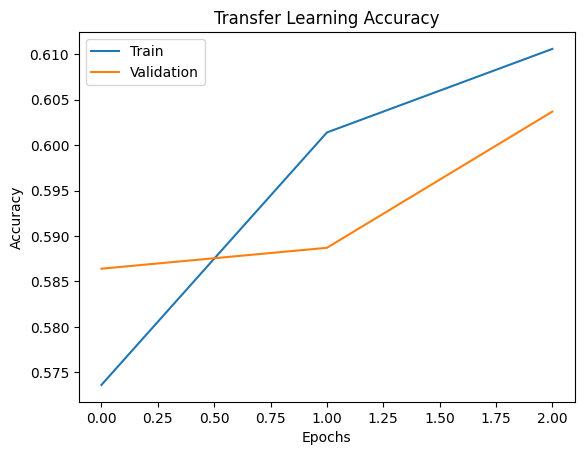

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("transfer_learning.png")
plt.show()

3. Confusion Matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 984s 6s/step


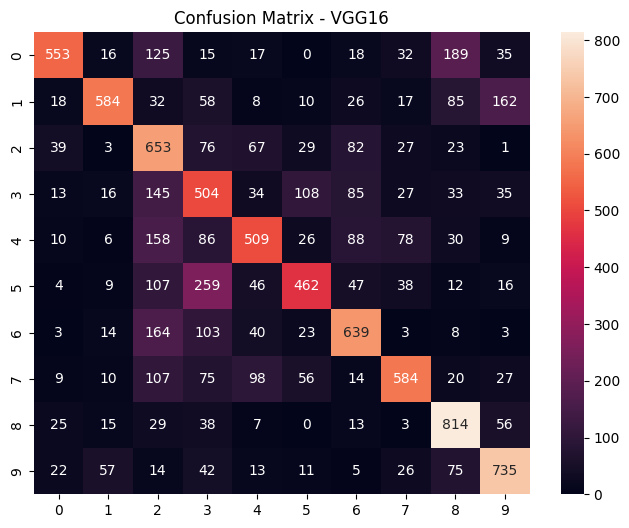

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = np.argmax(model.predict(x_test_resized, batch_size=64), axis=1)
y_true = np.argmax(y_test_cifar, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - VGG16")
plt.savefig("vgg16_cm.png")
plt.show()

4. Fine-Tuning

In [21]:
base.trainable = True

for layer in base.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    x_train_resized, y_train_cifar,
    epochs=3,
    validation_data=(x_test_resized, y_test_cifar)
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1591s 10s/step - accuracy: 0.6542 - loss: 0.9886 - val_accuracy: 0.6621 - val_loss: 0.9757
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1580s 10s/step - accuracy: 0.7322 - loss: 0.7903 - val_accuracy: 0.6942 - val_loss: 0.8943
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1577s 10s/step - accuracy: 0.7644 - loss: 0.6819 - val_accuracy: 0.7058 - val_loss: 0.8606


5. Evaluate AFTER Fine-Tuning

In [22]:
test_loss, test_acc = model.evaluate(x_test_resized, y_test_cifar)
print("Test Accuracy (Fine-Tuned):", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 957s 3s/step - accuracy: 0.7058 - loss: 0.8606
Test Accuracy (Fine-Tuned): 0.7057999968528748
